In [17]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgba
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch, PathPatch, Rectangle

CSV_FILE = "all-MCU2.csv"
df = pd.read_csv(CSV_FILE)

# ==========================================
# 1. SETUP & DATA
# ==========================================
REQUIRED_COLS = ("processor", "model", "status", "latency", "total_tokens")
missing_cols = [col for col in REQUIRED_COLS if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in df: {missing_cols}")

for col in ("processor", "model", "status"):
    df[col] = df[col].astype(str).str.strip().str.lower()

# ==========================================
# 2. CONFIGURATION
# ==========================================
MODEL_LABELS = {
    "gpt-4o": "G4o",
    "gpt-4o-mini": "G4o-m",
    "qwen32": "Qw32B",
    "qwen14": "Qw14B",
    "phi4": "Phi4",
    "codestral": "Co22B",
    "codestral-p": "Co22B-p",
}
PROCESSOR_LABELS = {
    "dp": "DP",
    "mc": "MC",
    "sg": "ArdSG",
    # "psg": "PyCPU-SG",
    # "tpusg": "PyTPU-SG",
}
MODEL_ORDER_PREF = list(MODEL_LABELS.values())
PROCESSOR_ORDER_PREF = ["dp", "mc", "sg"]
STATUS_ORDER = ["success", "failure"]

df["model_display"] = df["model"].map(MODEL_LABELS).fillna(df["model"])
print(MODEL_ORDER_PREF)

['G4o', 'G4o-m', 'Qw32B', 'Qw14B', 'Phi4', 'Co22B', 'Co22B-p']


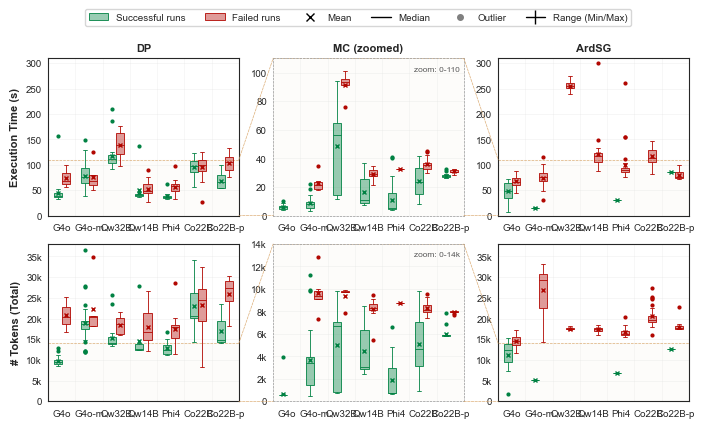

In [18]:
metrics = [
    {"col": "latency", "label": "Execution Time (s)", "fmt": None},
    {
        "col": "total_tokens",
        "label": "# Tokens (Total)",
        "fmt": lambda x, _: f"{int(x / 1000)}k" if x >= 1000 else f"{int(x)}",
    },
]

metric_limits = {
    "latency": (0, 310),
    "total_tokens": (0, 38000),
}

mc_metric_limits = {
    "latency": (0, 110),
    "total_tokens": (0, 14000),
}

# ==========================================
# 3. STYLE TOKENS (FONTS, SIZES, WEIGHTS, COLORS)
# ==========================================
# ── Font ─────────────────────────────────────────────────────────────────────
# Double column = 7.48 in; scale factor vs. original 18 in ≈ 0.42
# Elsevier: 7 pt normal, ≥6 pt subscripts [web:3]
FONT = {
    "family": "Arial",
    "title_size": 8,           # was 14 → panel titles at 8 pt
    "title_weight": "bold",
    "label_size": 8,           # was 13 → y-axis labels at 8 pt
    "label_weight": "bold",
    "legend_size": 7,          # was 12 → 7 pt legend (Elsevier floor)
    "tick_size": 7,   
    "zoom_note_size": 6,       # was 9  → 6 pt min (subscript floor)
}

# ── Style ─────────────────────────────────────────────────────────────────────
STYLE = {
    "group_separator_linewidth": 0.4,  # was 0.6
    "group_separator_alpha": 0.35,
    "grid_linewidth": 0.4,             # was 0.6
    "grid_alpha": 0.5,
    "box_linewidth": 0.6,              # was 1.0
    "box_width": 0.6,                  # was 0.7 → narrower for compact axes
    "box_fill_alpha": 0.4,
    "mean_marker_size": 3,             # was 5
    "outlier_marker_size": 2,          # was 3
    "zoom_linewidth": 0.5,             # was 0.9
    "zoom_line_alpha": 0.9,
    "mc_spine_linewidth": 0.6,         # was 1.0
    "legend_columns": 6,               # keep 6; reduce to 4 if legend overflows
}

COLORS = {
    "status_success_fill": "#008142",
    "status_success_edge": "#008142",
    "status_failure_fill": "#B10600",
    "status_failure_edge": "#B10600",
    "zoom_band": "#F5F0E6",
    "zoom_line": "#D9A66A",
    "group_separator": "0.85",
    "grid": "0.88",
    "zoom_spine": "0.65",
    "zoom_note_text": "0.35",
    "mean_marker": "black",
    "median_line": "black",
    "outlier": "gray",
}
 
STATUS_STYLES = {
    "success": {
        "facecolor": COLORS["status_success_fill"],
        "edgecolor": COLORS["status_success_edge"],
    },
    "failure": {
        "facecolor": COLORS["status_failure_fill"],
        "edgecolor": COLORS["status_failure_edge"],
    },
}
palette = {status: style["facecolor"] for status, style in STATUS_STYLES.items()}

# ==========================================
# 4. PLOTTING
# ==========================================
sns.set_style("white")
plt.rcParams["font.family"] = FONT["family"]

# Add this right after plt.rcParams["font.family"] = FONT["family"]
plt.rcParams.update({
    "font.size":         FONT["legend_size"],   # global fallback = 7 pt
    "axes.labelsize":    FONT["label_size"],     # 8 pt
    "axes.titlesize":    FONT["title_size"],     # 8 pt
    "xtick.labelsize":   7,                      # model name ticks
    "ytick.labelsize":   7,                      # value ticks
    "legend.fontsize":   FONT["legend_size"],    # 7 pt
    "legend.title_fontsize": FONT["label_size"], # 8 pt if legend has title
})

def patch_x_bounds(ax, patch):
    (x0, _), (x1, _) = ax.transData.inverted().transform(patch.get_extents().get_points())
    return min(x0, x1), max(x0, x1)


def status_for_box_center(box_center, n_models):
    nearest_model_idx = min(range(max(n_models, 1)), key=lambda idx: abs(box_center - idx))
    return STATUS_ORDER[0] if box_center <= nearest_model_idx else STATUS_ORDER[1]


def finite_x_values(line):
    values = []
    for value in line.get_xdata():
        try:
            numeric_value = float(value)
        except (TypeError, ValueError):
            continue
        if math.isfinite(numeric_value):
            values.append(numeric_value)
    return values


def style_boxplot_by_status(ax, n_models):
    box_patches = [patch for patch in ax.patches if isinstance(patch, PathPatch)]
    if not box_patches:
        return

    box_specs = []
    for patch in box_patches:
        x0, x1 = patch_x_bounds(ax, patch)
        box_center = (x0 + x1) / 2
        status = status_for_box_center(box_center, n_models)
        style = STATUS_STYLES[status]
        edge_color = style["edgecolor"]

        patch.set_facecolor(to_rgba(style["facecolor"], STYLE["box_fill_alpha"]))
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(STYLE["box_linewidth"])

        box_specs.append({
            "center": box_center,
            "x0": x0,
            "x1": x1,
            "edgecolor": edge_color,
        })

    line_tol = STYLE["box_width"] * 0.08
    for line in ax.lines:
        xdata = finite_x_values(line)
        if not xdata:
            continue

        x_min = min(xdata)
        x_max = max(xdata)
        x_center = sum(xdata) / len(xdata)

        matches = [
            spec
            for spec in box_specs
            if x_min >= spec["x0"] - line_tol and x_max <= spec["x1"] + line_tol
        ]
        if not matches:
            continue

        spec = min(matches, key=lambda item: abs(x_center - item["center"]))
        line.set_color(spec["edgecolor"])
        line.set_markeredgecolor(spec["edgecolor"])
        line.set_markerfacecolor(spec["edgecolor"])


def set_axis_limits_and_zoom_note(ax, proc, metric_col):
    if proc == "mc" and metric_col in mc_metric_limits:
        y0, y1 = mc_metric_limits[metric_col]
        ax.set_ylim(y0, y1)

        for spine in ax.spines.values():
            spine.set_linestyle((0, (2, 2)))
            spine.set_linewidth(STYLE["mc_spine_linewidth"])
            spine.set_color(COLORS["zoom_spine"])

        range_label = f"{int(y0)}-{int(y1 / 1000)}k" if metric_col == "total_tokens" else f"{int(y0)}-{int(y1)}"
        ax.text(
            0.98,
            0.95,
            f"zoom: {range_label}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=FONT["zoom_note_size"],
            color=COLORS["zoom_note_text"],
        )
    elif metric_col in metric_limits:
        ax.set_ylim(*metric_limits[metric_col])


def draw_zoom_lines(ax, y0, y1):
    for y in (y0, y1):
        ax.axhline(
            y=y,
            color=COLORS["zoom_line"],
            linewidth=STYLE["zoom_linewidth"],
            linestyle="--",
            alpha=STYLE["zoom_line_alpha"],
            zorder=0,
        )


def connect_zoom_lines(fig, src_ax, dst_ax, y0, y1):
    for y in (y0, y1):
        fig.add_artist(
            ConnectionPatch(
                xyA=(1.0, y),
                coordsA=src_ax.get_yaxis_transform(),
                xyB=(0.0, y),
                coordsB=dst_ax.get_yaxis_transform(),
                color=COLORS["zoom_line"],
                linewidth=STYLE["zoom_linewidth"],
                linestyle="--",
                alpha=STYLE["zoom_line_alpha"],
            )
        )


# fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 7), sharey=False)
# plt.subplots_adjust(top=0.915, hspace=0.13, wspace=0.1)

# Elsevier double column = 190 mm = 7.48 in [web:3]
# 2-row layout: height ≈ 7.48 / 1.8 ≈ 4.15 in (slightly taller than golden ratio
# to give the two subplot rows enough vertical breathing room)
ONE_MM = 1 / 25.4
fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(210 * ONE_MM, 105 * ONE_MM),  # 7.48 × 4.13 in
    sharey=False,
)
plt.subplots_adjust(top=0.88, bottom=0.05, hspace=0.18, wspace=0.18)

plot_order = MODEL_ORDER_PREF
for col_idx, proc in enumerate(PROCESSOR_ORDER_PREF):
    subset = df[df["processor"] == proc]

    if subset.empty:
        for row_idx in range(len(metrics)):
            axes[row_idx, col_idx].set_visible(False)
        continue

    for row_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        sns.boxplot(
            data=subset,
            x="model_display",
            y=metric["col"],
            hue="status",
            hue_order=STATUS_ORDER,
            order=plot_order,
            ax=ax,
            palette=palette,
            showmeans=True,
            meanprops={
                "marker": "x",
                "markeredgecolor": COLORS["mean_marker"],
                "markersize": STYLE["mean_marker_size"],
            },
            flierprops={
                "marker": "o",
                "markersize": STYLE["outlier_marker_size"],
                "markerfacecolor": COLORS["outlier"],
                "markeredgecolor": COLORS["outlier"],
            },
            width=STYLE["box_width"],
            linewidth=STYLE["box_linewidth"],
        )
        style_boxplot_by_status(ax, len(plot_order))

        for xpos in np.arange(len(plot_order) - 1) + 0.5:
            ax.axvline(
                x=xpos,
                color=COLORS["group_separator"],
                linewidth=STYLE["group_separator_linewidth"],
                alpha=STYLE["group_separator_alpha"],
                zorder=0,
            )

        if ax.get_legend():
            ax.get_legend().remove()
        ax.set_xlabel("")
        ax.grid(
            axis="y",
            color=COLORS["grid"],
            linewidth=STYLE["grid_linewidth"],
            linestyle="-",
            alpha=STYLE["grid_alpha"],
        )

        ax.set_ylabel(
            metric["label"] if col_idx == 0 else "",
            fontweight=FONT["label_weight"],
            fontsize=FONT["label_size"],
        )
        # ax.tick_params(axis="y", pad=0)

        ax.tick_params(axis="y", labelsize=7, pad=1)
        ax.tick_params(axis="x", labelsize=7, pad=2)
        
        if row_idx == 0:
            title = PROCESSOR_LABELS.get(proc, proc)
            if proc == "mc":
                title += " (zoomed)"
            ax.set_title(
                title,
                fontsize=FONT["title_size"],
                weight=FONT["title_weight"],
                pad=5,
            )

        if metric["fmt"]:
            ax.yaxis.set_major_formatter(FuncFormatter(metric["fmt"]))

        set_axis_limits_and_zoom_note(ax, proc, metric["col"])

# ==========================================
# 5. ZOOM-LINK INDICATORS (MC <-> DP/ArdSG)
# ==========================================
for row_idx, metric in enumerate(metrics):
    y0, y1 = mc_metric_limits[metric["col"]]

    dp_ax = axes[row_idx, 0]
    mc_ax = axes[row_idx, 1]
    sg_ax = axes[row_idx, 2]

    dp_ax.axhspan(y0, y1, color=COLORS["zoom_band"], alpha=0.20, zorder=0)
    sg_ax.axhspan(y0, y1, color=COLORS["zoom_band"], alpha=0.20, zorder=0)
    mc_ax.set_facecolor(COLORS["zoom_band"])
    mc_ax.patch.set_alpha(0.20)

    for axis in (dp_ax, mc_ax, sg_ax):
        draw_zoom_lines(axis, y0, y1)

    connect_zoom_lines(fig, dp_ax, mc_ax, y0, y1)
    connect_zoom_lines(fig, mc_ax, sg_ax, y0, y1)

# ==========================================
# 6. CUSTOM LEGEND
# ==========================================
legend_elements = [
    Rectangle(
        (0, 0),
        1,
        1,
        facecolor=to_rgba(COLORS["status_success_fill"], STYLE["box_fill_alpha"]),
        edgecolor=COLORS["status_success_edge"],
        linewidth=STYLE["box_linewidth"],
        label="Successful runs",
    ),
    Rectangle(
        (0, 0),
        1,
        1,
        facecolor=to_rgba(COLORS["status_failure_fill"], STYLE["box_fill_alpha"]),
        edgecolor=COLORS["status_failure_edge"],
        linewidth=STYLE["box_linewidth"],
        label="Failed runs",
    ),
    Line2D([0], [0], color=COLORS["mean_marker"], marker="x", linestyle="None", markersize=6, label="Mean"),
    Line2D([0], [0], color=COLORS["median_line"], linewidth=1, linestyle="-", label="Median"),
    Line2D([0], [0], color=COLORS["outlier"], marker="o", linestyle="None", markersize=4, label="Outlier"),
    Line2D([0], [0], color=COLORS["median_line"], linewidth=1, linestyle="-", marker="|", markersize=10, label="Range (Min/Max)"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=STYLE["legend_columns"],
    bbox_to_anchor=(0.5, 1.01),
    fontsize=FONT["legend_size"],
    frameon=True,
    )

plt.savefig("figs/box_MCU.pdf", dpi=500, bbox_inches="tight")
plt.savefig("figs/box_MCU.png", dpi=500, bbox_inches="tight")
plt.show()

# The statistics export was deleted by accident, but should be able to be restored from the previous commits. No further edits were done to this part since cloned to laptop

In [19]:
# ==========================================
# EXPORT BOX PLOT STATISTICS
# ==========================================
# Calculate all statistics used in box plots for direct reproduction

def calculate_boxplot_stats(group_data):
    """Calculate all box plot statistics for a group."""
    if group_data.empty:
        return {
            "count": 0,
            "min": None,
            "q1": None,
            "median": None,
            "q3": None,
            "max": None,
            "mean": None,
            "iqr": None,
            "lower_whisker": None,
            "upper_whisker": None,
            "outliers": None,
            "n_outliers": 0,
        }

    q1 = group_data.quantile(0.25)
    q3 = group_data.quantile(0.75)
    iqr = q3 - q1

    # Calculate whiskers (1.5 * IQR rule used by matplotlib/seaborn).
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    within_bounds = group_data[(group_data >= lower_bound) & (group_data <= upper_bound)]
    lower_whisker = within_bounds.min() if not within_bounds.empty else group_data.min()
    upper_whisker = within_bounds.max() if not within_bounds.empty else group_data.max()

    outliers = group_data[(group_data < lower_bound) | (group_data > upper_bound)]

    return {
        "count": len(group_data),
        "min": group_data.min(),
        "q1": q1,
        "median": group_data.median(),
        "q3": q3,
        "max": group_data.max(),
        "mean": group_data.mean(),
        "iqr": iqr,
        "lower_whisker": lower_whisker,
        "upper_whisker": upper_whisker,
        "outliers": outliers.tolist(),
        "n_outliers": len(outliers),
    }

all_stats = []
metrics_to_export = (
    {"col": "latency", "label": "Execution Time (s)"},
    {"col": "total_tokens", "label": "# Tokens (Total)"},
)
statuses = ("success", "failure")
processors = df["processor"].unique()
models = df["model"].unique()

for metric in metrics_to_export:
    metric_col = metric["col"]

    for processor in processors:
        for model in models:
            for status in statuses:
                subset = df[
                    (df["processor"] == processor)
                    & (df["model"] == model)
                    & (df["status"] == status)
                ][metric_col].dropna()

                stats_record = {
                    "metric": metric_col,
                    "processor": processor,
                    "processor_label": PROCESSOR_LABELS.get(processor, processor),
                    "model": model,
                    "model_label": MODEL_LABELS.get(model, model),
                    "status": status,
                    **calculate_boxplot_stats(subset),
                }
                all_stats.append(stats_record)

stats_df = pd.DataFrame(all_stats)
stats_df_clean = stats_df[stats_df["count"] > 0].drop(columns=["outliers"])

output_file = "cost-time_statistics_MCU.csv"
stats_df_clean.to_csv(output_file, index=False)
print(f"✔ Exported all box plot statistics to: {output_file}")
print(f"  Total records: {len(stats_df_clean)}")
print("  Metrics included: latency, total_tokens")

print("\n" + "=" * 60)
print("STATISTICS SUMMARY")
print("=" * 60)
print(f"Metrics: {', '.join([m['col'] for m in metrics_to_export])}")
print(f"Processors: {', '.join(stats_df_clean['processor'].unique())}")
print(f"Models: {', '.join(stats_df_clean['model'].unique())}")
print(f"Status values: {', '.join(stats_df_clean['status'].unique())}")
print("\nColumns in exported CSV:")
for col in stats_df_clean.columns:
    print(f"  - {col}")
print("=" * 60)

print("\nSample statistics (first few rows):")
display(stats_df_clean.head(10))

✔ Exported all box plot statistics to: cost-time_statistics_MCU.csv
  Total records: 76
  Metrics included: latency, total_tokens

STATISTICS SUMMARY
Metrics: latency, total_tokens
Processors: sg, mc, dp
Models: codestral, gpt-4o, gpt-4o-mini, phi4, codestral-p, qwen14, qwen32
Status values: failure, success

Columns in exported CSV:
  - metric
  - processor
  - processor_label
  - model
  - model_label
  - status
  - count
  - min
  - q1
  - median
  - q3
  - max
  - mean
  - iqr
  - lower_whisker
  - upper_whisker
  - n_outliers

Sample statistics (first few rows):


,metric,processor,processor_label,model,model_label,status,count,min,q1,median,q3,max,mean,iqr,lower_whisker,upper_whisker,n_outliers
1,latency,sg,ArdSG,codestral,Co22B,failure,30,81.610000,105.995000,114.195000,130.185000,146.610000,117.024000,24.190000,81.610000,146.610000,0
2,latency,sg,ArdSG,gpt-4o,G4o,success,11,7.733686,34.312718,48.411749,65.161059,72.775711,48.748919,30.848342,7.733686,72.775711,0
3,latency,sg,ArdSG,gpt-4o,G4o,failure,19,45.386724,59.848777,65.306292,74.887673,87.921943,67.378662,15.038896,45.386724,87.921943,0
4,latency,sg,ArdSG,gpt-4o-mini,G4o-m,success,2,15.251896,15.500004,15.748111,15.996219,16.244326,15.748111,0.496215,15.251896,16.244326,0
5,latency,sg,ArdSG,gpt-4o-mini,G4o-m,failure,28,31.090000,68.858940,75.237158,83.639447,114.929878,74.958385,14.780507,48.970000,102.360403,2
6,latency,sg,ArdSG,phi4,Phi4,success,1,30.360000,30.360000,30.360000,30.360000,30.360000,30.360000,0.000000,30.360000,30.360000,0
7,latency,sg,ArdSG,phi4,Phi4,failure,29,76.670000,85.570000,90.350000,94.360000,260.940000,99.920345,8.790000,76.670000,103.790000,4
8,latency,sg,ArdSG,codestral-p,Co22B-p,success,1,85.380000,85.380000,85.380000,85.380000,85.380000,85.380000,0.000000,85.380000,85.380000,0
9,latency,sg,ArdSG,codestral-p,Co22B-p,failure,29,71.970000,73.910000,76.300000,86.540000,99.040000,80.423793,12.630000,71.970000,99.040000,0
11,latency,sg,ArdSG,qwen14,Qw14B,failure,30,88.490000,106.537500,117.050000,122.832500,299.850000,121.342667,16.295000,88.490000,133.470000,2
